In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

from astropy.convolution import Gaussian1DKernel, convolve

In [2]:
cat = Table(fitsio.read('/global/cfs/cdirs/desi/spectro/redux/himalayas/exposures-himalayas.fits'))

In [3]:
fiber = 4720
tileid = 1650
camera = 'r'
petal = 9

mask = cat['TILEID']==tileid
# cat[mask]
expid = cat['EXPID'][mask][0]
night = cat['NIGHT'][mask][0]

coadd_fn = '/global/cfs/cdirs/desi/spectro/redux/himalayas/tiles/cumulative/{}/{}/coadd-{}-{}-thru{}.fits'.format(tileid, night, petal, tileid, night)
frame_fn = '/global/cfs/cdirs/desi/spectro/redux/himalayas/exposures/{}/{}/frame-{}{}-{}.fits.gz'.format(night, str(expid).zfill(8), camera, petal, str(expid).zfill(8))
sframe_fn = '/global/cfs/cdirs/desi/spectro/redux/himalayas/exposures/{}/{}/sframe-{}{}-{}.fits.gz'.format(night, str(expid).zfill(8), camera, petal, str(expid).zfill(8))
cframe_fn = '/global/cfs/cdirs/desi/spectro/redux/himalayas/exposures/{}/{}/cframe-{}{}-{}.fits.gz'.format(night, str(expid).zfill(8), camera, petal, str(expid).zfill(8))

print(tileid, expid, night)
print(coadd_fn)

1650 122893 20220219
/global/cfs/cdirs/desi/spectro/redux/himalayas/tiles/cumulative/1650/20220219/coadd-9-1650-thru20220219.fits


In [4]:
gauss_kernel = Gaussian1DKernel(stddev=5)

--------

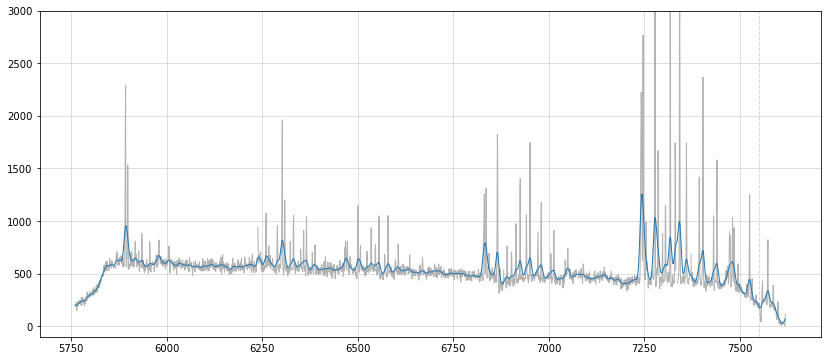

In [5]:
fm = fitsio.read(frame_fn, ext='FIBERMAP')
flux = fitsio.read(frame_fn, ext='FLUX')
wave = fitsio.read(frame_fn, ext='WAVELENGTH')
msk = fitsio.read(frame_fn, ext='MASK')
flux[msk!=0] = np.nan

index = np.where(fm['FIBER']==fiber)[0][0]
flux_smooth = convolve(flux[index], gauss_kernel, boundary='extend')

plt.figure(figsize=(14, 6))
plt.plot(wave, flux[index], lw=1, color='0.7')
plt.plot(wave, flux_smooth, lw=1)
plt.ylim(-100, 3000)
plt.axvline(7552, lw=1, ls='--', color='r', alpha=0.2)
plt.grid(alpha=0.5)
plt.show()

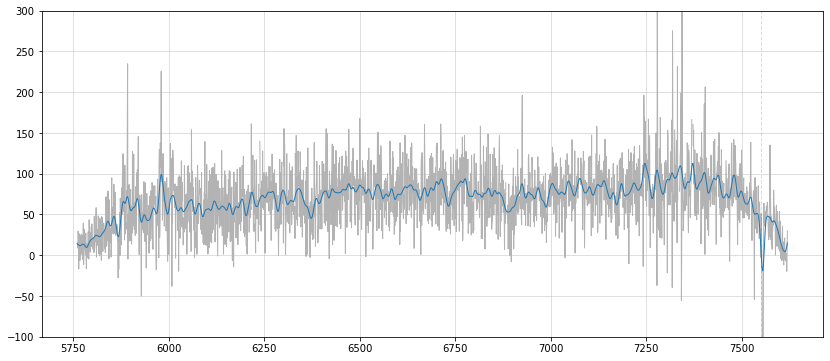

In [6]:
fm = fitsio.read(sframe_fn, ext='FIBERMAP')
flux = fitsio.read(sframe_fn, ext='FLUX')
wave = fitsio.read(sframe_fn, ext='WAVELENGTH')
msk = fitsio.read(sframe_fn, ext='MASK')
flux[msk!=0] = np.nan

index = np.where(fm['FIBER']==fiber)[0][0]
flux_smooth = convolve(flux[index], gauss_kernel, boundary='extend')

plt.figure(figsize=(14, 6))
plt.plot(wave, flux[index], lw=1, color='0.7')
plt.plot(wave, flux_smooth, lw=1)
plt.ylim(-100, 300)
plt.axvline(7552, lw=1, ls='--', color='r', alpha=0.2)
plt.grid(alpha=0.5)
plt.show()

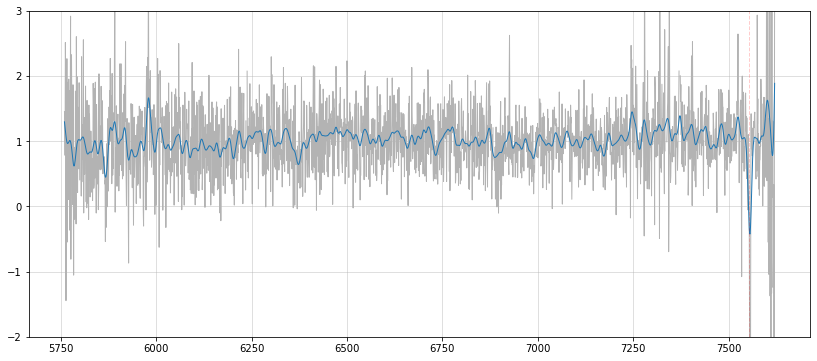

In [7]:
fm = fitsio.read(cframe_fn, ext='FIBERMAP')
flux = fitsio.read(cframe_fn, ext='FLUX')
wave = fitsio.read(cframe_fn, ext='WAVELENGTH')
msk = fitsio.read(cframe_fn, ext='MASK')
flux[msk!=0] = np.nan

index = np.where(fm['FIBER']==fiber)[0][0]
flux_smooth = convolve(flux[index], gauss_kernel, boundary='extend')

plt.figure(figsize=(14, 6))
plt.plot(wave, flux[index], lw=1, color='0.7')
plt.plot(wave, flux_smooth, lw=1)
plt.ylim(-2, 3)
plt.axvline(7552, lw=1, ls='--', color='r', alpha=0.2)
plt.grid(alpha=0.5)
plt.show()